# This program is used to simulate complacency effect on the state of OH

In [115]:
# Import all the libraries
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
import re
import numpy as np
from pprint import pprint
from sklearn.linear_model import LinearRegression
import numpy as np

In [116]:
file_path = (r"..\..\final_data\GA.csv")

GA_data = pd.read_csv(file_path)

In [117]:
GA_data

,precinct,pri_dem_CLINTON,pri_dem_O'MALLEY,pri_dem_SANDERS,pri_dem_STEINBERG,pri_rep_BUSH,pri_rep_CARSON,pri_rep_CHRISTIE,pri_rep_CRUZ,pri_rep_FIORINA,...,pri_rep_RUBIO,pri_rep_SANTORUM,pri_rep_TRUMP,gen_dem_CLINTON,gen_lib_JOHNSON,gen_rep_TRUMP,dem_primary_total,rep_primary_total,dem_general_total,rep_general_total
0,APPLING1B,23,1,12,1,5,34,0,108,1,...,54,0,165,92,9,685,37,382,92,685
1,APPLING1C,14,1,5,0,3,28,0,88,0,...,45,0,125,42,5,496,20,303,42,496
2,APPLING2,284,3,41,1,3,28,0,45,0,...,27,0,96,742,10,427,329,206,742,427
3,APPLING3A,1,0,3,0,0,10,0,41,0,...,13,0,48,4,4,209,4,116,4,209
4,APPLING3A1,11,0,6,0,3,26,0,68,0,...,18,0,59,17,1,319,17,180,17,319
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2816,WORTHSHINGLER,19,0,8,1,3,12,0,50,0,...,20,0,111,47,4,337,28,201,47,337
2817,WORTHSUMNER,27,0,6,0,1,22,0,56,0,...,10,0,135,91,3,418,33,226,91,418
2818,WORTHSYLVER EAST,46,1,16,1,7,36,0,83,1,...,51,0,188,162,25,664,64,387,162,664
2819,WORTHSYLVESTER,314,0,38,1,6,14,1,82,1,...,26,0,154,905,16,562,353,303,905,562


In [118]:
GA_data['primary_total_votes'] = GA_data['dem_primary_total'] + GA_data['rep_primary_total']
GA_data['general_total_votes'] = GA_data['dem_general_total'] + GA_data['rep_general_total']

In [119]:
# Remove the top 3 rows with the largest general_total_votes from GA_data, outliers
GA_data = GA_data.sort_values('general_total_votes', ascending=False).iloc[4:].reset_index(drop=True)

In [120]:
# Print out the top 5 rows with the largest general_total_votes
top5 = GA_data.sort_values('general_total_votes', ascending=False)
top5

,precinct,pri_dem_CLINTON,pri_dem_O'MALLEY,pri_dem_SANDERS,pri_dem_STEINBERG,pri_rep_BUSH,pri_rep_CARSON,pri_rep_CHRISTIE,pri_rep_CRUZ,pri_rep_FIORINA,...,pri_rep_TRUMP,gen_dem_CLINTON,gen_lib_JOHNSON,gen_rep_TRUMP,dem_primary_total,rep_primary_total,dem_general_total,rep_general_total,primary_total_votes,general_total_votes
0,CHATHAMNAN,19916,72,7507,51,274,1522,50,7055,36,...,10738,62290,3503,45688,27546,30671,62290,45688,58217,107978
1,CHEROKEENAN,4844,29,4442,25,168,2524,61,12899,40,...,18469,25231,5015,80649,9340,50327,25231,80649,59667,105880
2,HENRYNAN,15795,38,4468,35,161,1705,33,8220,34,...,11375,50057,2505,45724,20336,28289,50057,45724,48625,95781
3,FORSYTHNAN,3707,24,3153,12,220,1776,45,9987,34,...,15736,23462,4091,69851,6896,42318,23462,69851,49214,93313
4,CLAYTONNAN,25151,60,5557,38,62,531,13,1859,15,...,3264,78220,1647,12645,30806,7770,78220,12645,38576,90865
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2812,FORSYTH15 HEARDSVILLE-7,0,0,2,0,0,0,0,1,0,...,3,4,1,18,2,8,4,18,10,22
2813,FULTON03P2,5,0,0,0,0,0,0,0,0,...,0,21,0,1,5,0,21,1,5,22
2814,FORSYTH10 MIDWAY-9,1,0,1,0,0,0,0,1,0,...,5,1,2,17,2,9,1,17,11,18
2815,FULTONUC02B,3,0,1,0,0,0,0,4,0,...,0,10,0,6,4,4,10,6,8,16


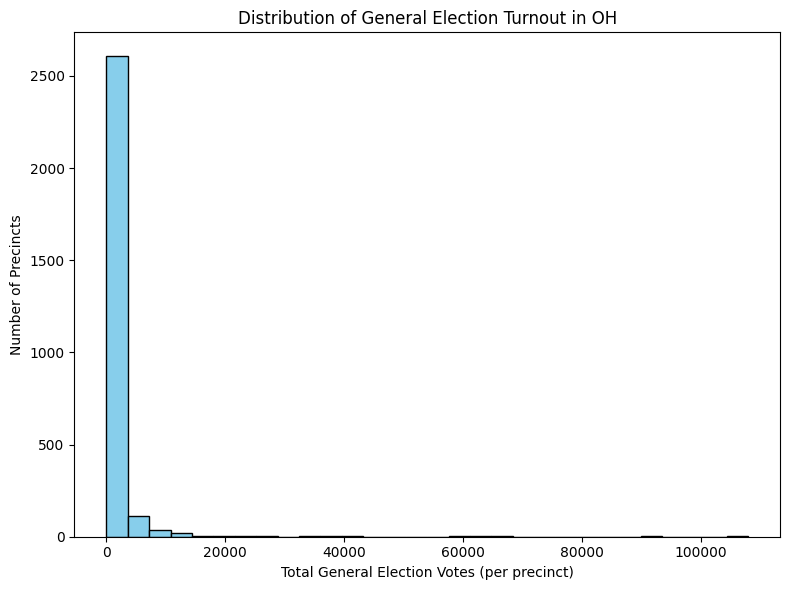

In [121]:
#Distribution of total general votes (Dem + Rep) per precinct

plt.figure(figsize=(8, 6))
plt.hist(GA_data['general_total_votes'], bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Total General Election Votes (per precinct)')
plt.ylabel('Number of Precincts')
plt.title('Distribution of General Election Turnout in OH')
plt.tight_layout()

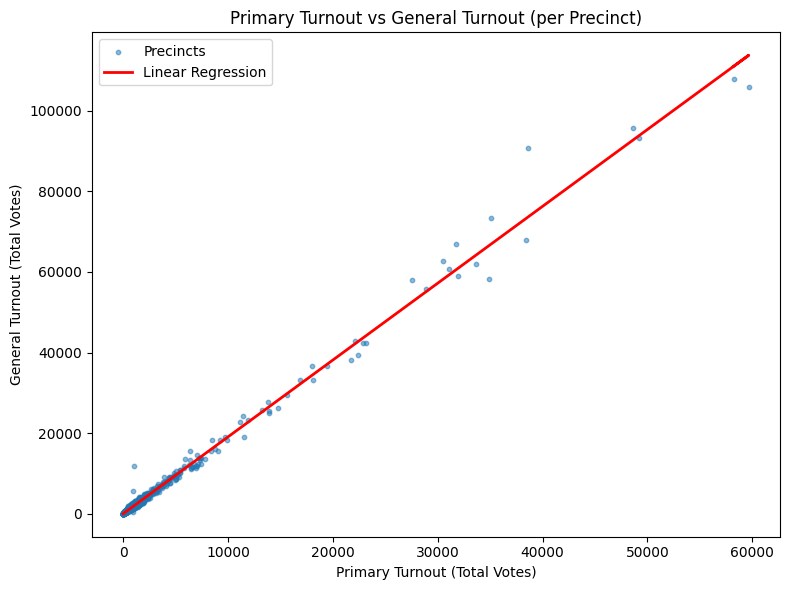

In [122]:
# Prepare X and y for regression
X = GA_data['primary_total_votes'].values.reshape(-1, 1)
y = GA_data['general_total_votes'].values

# Fit linear regression
reg = LinearRegression()
reg.fit(X, y)

# Predict values for the regression line
y_pred = reg.predict(X)

# Plot: Primary turnout vs General turnout with regression line
plt.figure(figsize=(8, 6))
plt.scatter(GA_data['primary_total_votes'], GA_data['general_total_votes'], alpha=0.5, s=10, label='Precincts')
plt.plot(GA_data['primary_total_votes'], y_pred, color='red', linewidth=2, label='Linear Regression')
plt.xlabel('Primary Turnout (Total Votes)')
plt.ylabel('General Turnout (Total Votes)')
plt.title('Primary Turnout vs General Turnout (per Precinct)')
plt.legend()
plt.tight_layout()
plt.show()

In [123]:
# After fitting the model
beta_0 = reg.intercept_
beta_1 = reg.coef_[0]

print(f"Intercept (β₀): {beta_0:.4f}")
print(f"Slope (β₁): {beta_1:.4f}")

Intercept (β₀): 23.7332
Slope (β₁): 1.9064


In [124]:
# Estimate precinct size based geometric approach
# Calculate probability of voting for each party in the general election
GA_data["general_turnout"] = GA_data["rep_general_total"] + GA_data["dem_general_total"]
GA_data["primary_turnout"] = GA_data["rep_primary_total"] + GA_data["dem_primary_total"]
general_turnoutprob = 0.71 # General turnout prob for Rep
primary_turnoutprob= 0.42 # Primary turnout prob for Rep
m = general_turnoutprob / primary_turnoutprob
GA_data["general_turnout_est"] = (GA_data['primary_turnout'] + m * GA_data['general_turnout']) / (1 + m **2)
GA_data["precinct_size"] = GA_data["general_turnout_est"] / primary_turnoutprob 

In [125]:
# Calculate the margin of each precinct margin = abs(rep_primary_total - dem_primary_total) / (rep_primary_total + dem_primary_total)
GA_data['primary_margin'] = np.abs(GA_data['rep_primary_total'] - GA_data['dem_primary_total']) / (GA_data['rep_primary_total'] + GA_data['dem_primary_total'])


In [126]:
# Calculate estimated number of Democratic voters per precinct
GA_data['dem_voters'] = (GA_data['dem_primary_total'] / (GA_data['dem_primary_total'] + GA_data['rep_primary_total'])) * GA_data['precinct_size']
GA_data['rep_voters'] = (GA_data['rep_primary_total'] / (GA_data['dem_primary_total'] + GA_data['rep_primary_total'])) * GA_data['precinct_size']

In [127]:
# Determine the winner based on primary totals
GA_data['primary_winner'] = np.where(
    GA_data['rep_primary_total'] > GA_data['dem_primary_total'], 'rep', 'dem'
)  

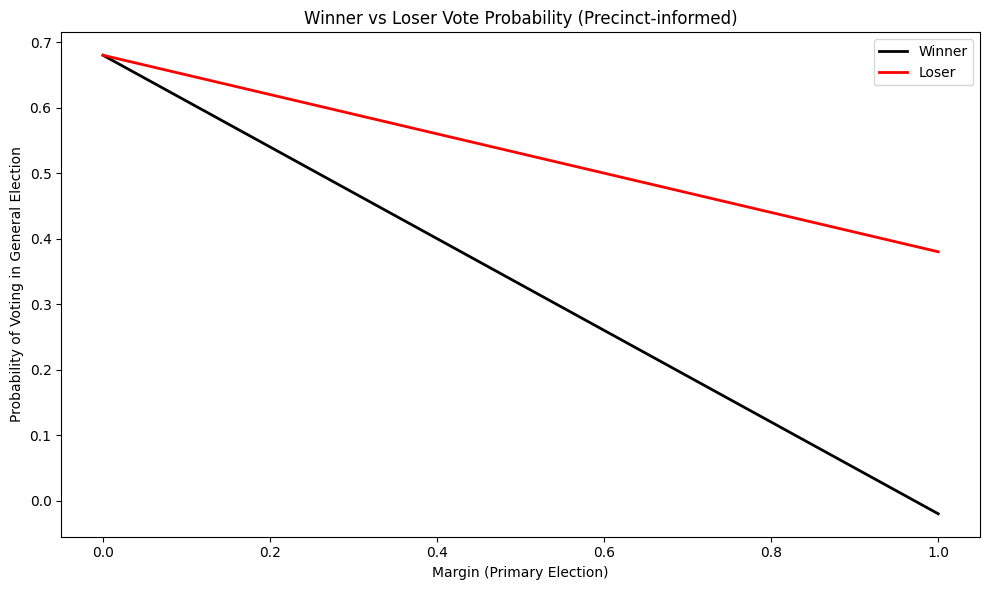

In [128]:
# Plotting vote chance
# Define x range: margin from 0 (tie) to 1 (blowout)
margins = np.linspace(0, 1, 200)

# Parameters
b = 0.68          # max vote probability at tie
m_w = 0.7      # steeper slope for winner
m_l = 0.3        # flatter slope for loser

# Calculate probabilities
prob_winner = b - m_w * margins
prob_loser = b - m_l * margins

# Plot
plt.figure(figsize=(10, 6))
plt.plot(margins, prob_winner, label="Winner", color='black', linewidth=2)
plt.plot(margins, prob_loser, label="Loser", color='red', linewidth=2)

# Labels and titles
plt.title("Winner vs Loser Vote Probability (Precinct-informed)")
plt.xlabel("Margin (Primary Election)")
plt.ylabel("Probability of Voting in General Election")
plt.legend()
plt.tight_layout()

In [129]:
# 1. Estimate number of non-primary voters for each party
GA_data['predicted_dem_gen'] = np.where(
    GA_data['primary_winner'] == 'dem',
    (b - GA_data['primary_margin'] * m_w)* GA_data['dem_voters'],  
    (b - GA_data['primary_margin'] * m_l)* GA_data['dem_voters']
)

# For Republicans
GA_data['predicted_rep_gen'] = np.where(
    GA_data['primary_winner'] == 'rep',
    (b - GA_data['primary_margin'] * m_w)* GA_data['rep_voters'],  
    (b - GA_data['primary_margin'] * m_l)* GA_data['rep_voters']
)

In [130]:
# Compare to actual general vote shares
GA_data['actual_general_rep_share'] = GA_data['rep_general_total'] / (
    GA_data['rep_general_total'] + GA_data['dem_general_total']
)
GA_data['predicted_rep_share'] = GA_data['predicted_rep_gen'] / (
    GA_data['predicted_rep_gen'] + GA_data['predicted_dem_gen']
)
GA_data['primary_rep_voteshare'] = GA_data['rep_primary_total'] / (
    GA_data['rep_primary_total'] + GA_data['dem_primary_total']
)



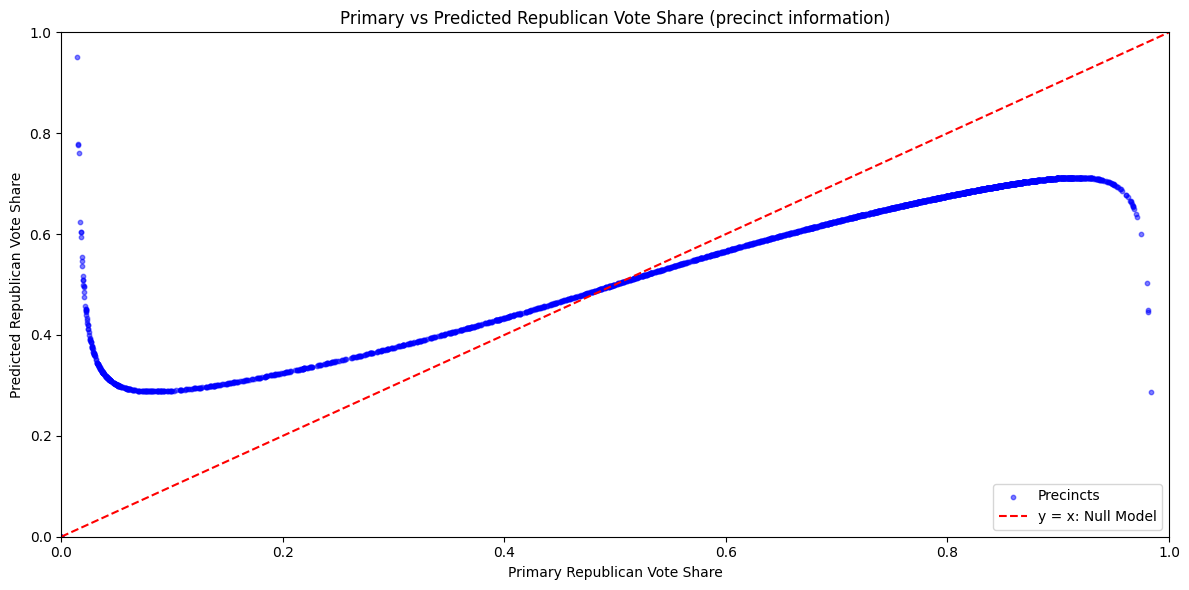

In [131]:
plt.figure(figsize=(12, 6))
plt.scatter(
    x=GA_data['primary_rep_voteshare'], 
    y=GA_data['predicted_rep_share'], 
    color='blue', label='Precincts', alpha=0.5, s=10
)
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='y = x: Null Model')
plt.title('Primary vs Predicted Republican Vote Share (precinct information)')
plt.xlabel('Primary Republican Vote Share')
plt.ylabel('Predicted Republican Vote Share')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()


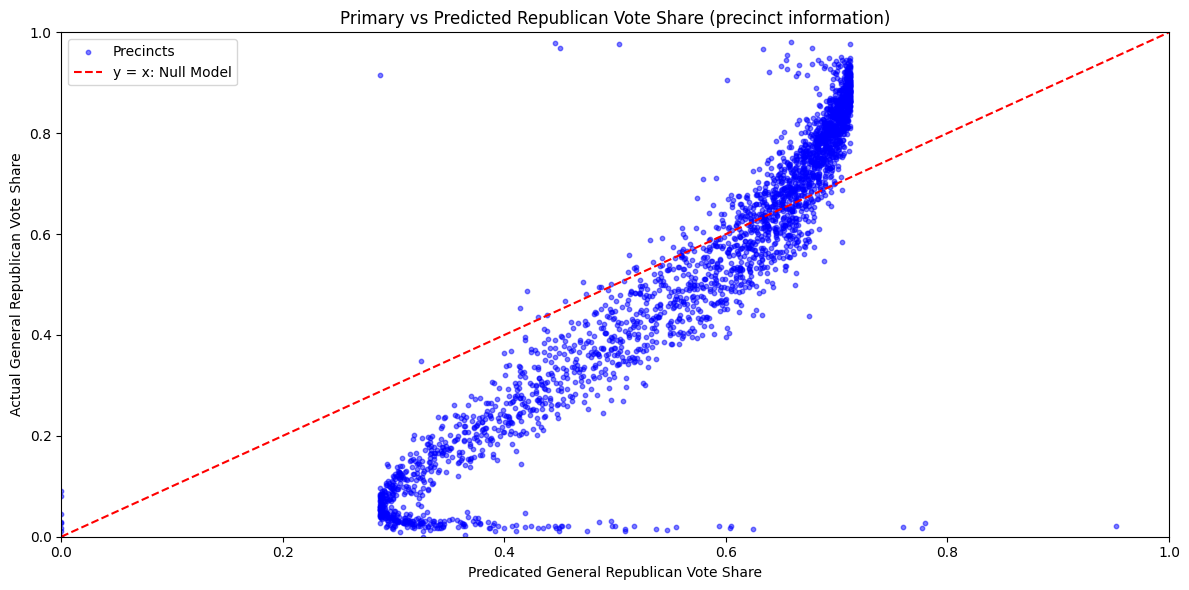

In [132]:
plt.figure(figsize=(12, 6))
plt.scatter(
    x=GA_data['predicted_rep_share'], 
    y=GA_data['actual_general_rep_share'], 
    color='blue', label='Precincts', alpha=0.5, s=10
)
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='y = x: Null Model')
plt.title('Primary vs Predicted Republican Vote Share (precinct information)')
plt.xlabel('Predicated General Republican Vote Share')
plt.ylabel('Actual General Republican Vote Share')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

## State - level Information

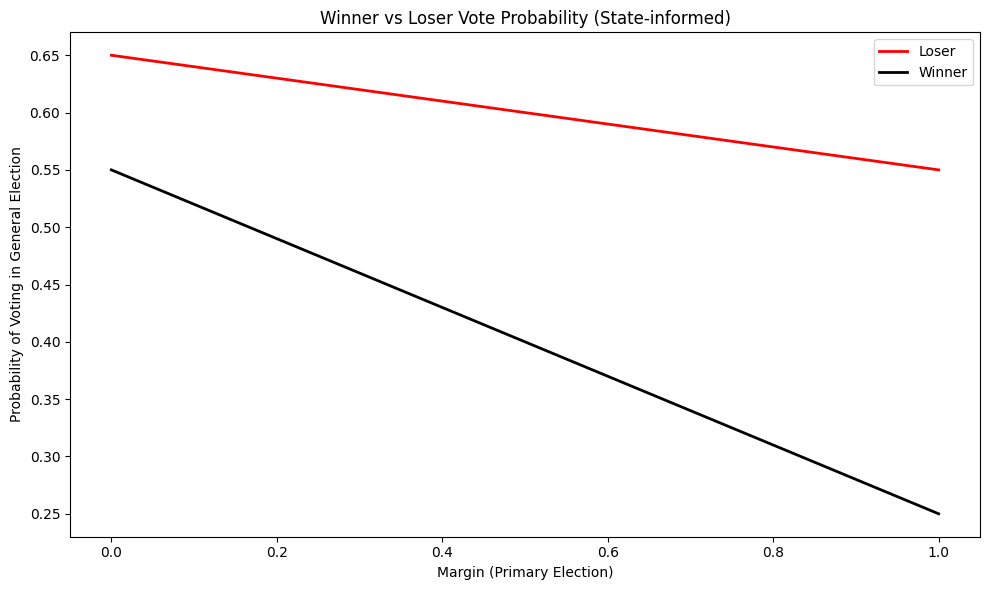

In [133]:
# Plotting vote chance
# Define x range: margin from 0 (tie) to 1 (blowout)
margins = np.linspace(0, 1, 200)

# Parameters
b_w = 0.55          # max vote probability at tie
b_l = 0.65
m_w = 0.3      # steeper slope for winner
m_l = 0.1        # flatter slope for loser

# Calculate probabilities
prob_winner = b_w - m_w * margins
prob_loser = b_l - m_l * margins

# Plot
plt.figure(figsize=(10, 6))
plt.plot(margins, prob_loser, label="Loser", color='red', linewidth=2)
plt.plot(margins, prob_winner, label="Winner", color='black', linewidth=2)

# Labels and titles
plt.title("Winner vs Loser Vote Probability (State-informed)")
plt.xlabel("Margin (Primary Election)")
plt.ylabel("Probability of Voting in General Election")
plt.legend()
plt.tight_layout()

In [134]:
# Determine the winner based on primary totals
# GA_data['state_primary_winner'] = np.where(
#     GA_data['rep_primary_total'].sum() > GA_data['dem_primary_total'].sum(), 'rep', 'dem'
# )  
GA_data['state_primary_winner'] = np.where(
    GA_data['rep_primary_total'].sum() > GA_data['dem_primary_total'].sum(), 'rep', 'dem'
)  

In [135]:
GA_data

,precinct,pri_dem_CLINTON,pri_dem_O'MALLEY,pri_dem_SANDERS,pri_dem_STEINBERG,pri_rep_BUSH,pri_rep_CARSON,pri_rep_CHRISTIE,pri_rep_CRUZ,pri_rep_FIORINA,...,primary_margin,dem_voters,rep_voters,primary_winner,predicted_dem_gen,predicted_rep_gen,actual_general_rep_share,predicted_rep_share,primary_rep_voteshare,state_primary_winner
0,CHATHAMNAN,19916,72,7507,51,274,1522,50,7055,36,...,0.053678,70306.974801,78283.061937,rep,46676.551428,50291.001141,0.423123,0.518637,0.526839,rep
1,CHEROKEENAN,4844,29,4442,25,168,2524,61,12899,40,...,0.686929,23057.046687,124238.970947,rep,10927.224687,24742.143069,0.761702,0.693652,0.843465,rep
2,HENRYNAN,15795,38,4468,35,161,1705,33,8220,34,...,0.163558,54345.392500,75598.780902,rep,34288.282386,42751.829663,0.477381,0.554929,0.581779,rep
3,FORSYTHNAN,3707,24,3153,12,220,1776,45,9987,34,...,0.719755,17898.256121,109834.455121,rep,8306.108824,19349.735970,0.748567,0.699662,0.859877,rep
4,CLAYTONNAN,25151,60,5557,38,62,531,13,1859,15,...,0.597159,94721.811875,23891.075708,dem,24816.053953,11965.901255,0.139162,0.325320,0.201421,rep
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2812,FORSYTH15 HEARDSVILLE-7,0,0,2,0,0,0,0,1,0,...,0.600000,5.825129,23.300514,rep,2.912564,6.058134,0.818182,0.675325,0.800000,rep
2813,FULTON03P2,5,0,0,0,0,0,0,0,0,...,1.000000,26.039677,0.000000,dem,-0.520794,0.000000,0.045455,-0.000000,0.000000,rep
2814,FORSYTH10 MIDWAY-9,1,0,1,0,0,0,0,1,0,...,0.636364,4.648988,20.920446,rep,2.273778,4.906796,0.944444,0.683343,0.818182,rep
2815,FULTONUC02B,3,0,1,0,0,0,0,4,0,...,0.000000,10.815577,10.815577,dem,7.354592,7.354592,0.375000,0.500000,0.500000,rep


In [136]:
# 1. Estimate number of non-primary voters for each party
GA_data['predicted_dem_gen_state'] = np.where(
    GA_data['state_primary_winner'] == 'dem',
    (b_w - GA_data['primary_margin'] * m_w)* GA_data['dem_voters'],  
    (b_l - GA_data['primary_margin'] * m_l)* GA_data['dem_voters']
)

# For Republicans
GA_data['predicted_rep_gen_state'] = np.where(
    GA_data['state_primary_winner'] == 'rep',
    (b_w - GA_data['primary_margin'] * m_w)* GA_data['rep_voters'],  
    (b_l - GA_data['primary_margin'] * m_l)* GA_data['rep_voters']
)


In [137]:
# Compute predicted Republican vote share based on state primary winner
GA_data['predicted_rep_share_state'] = GA_data['predicted_rep_gen_state'] / (
    GA_data['predicted_rep_gen_state'] + GA_data['predicted_dem_gen_state']
)

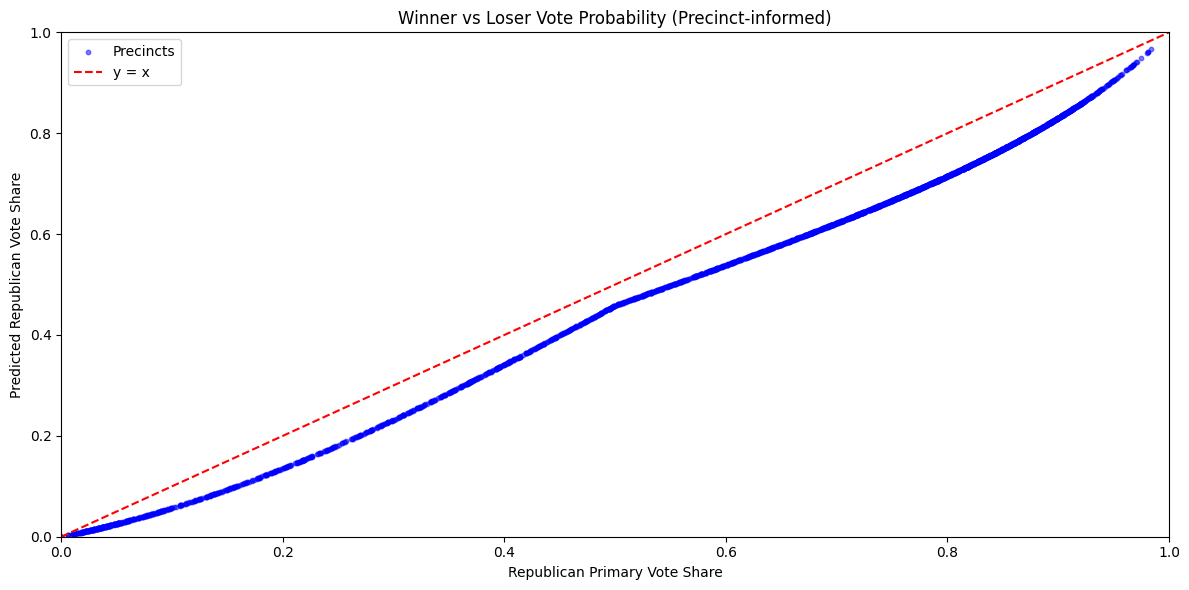

In [138]:
plt.figure(figsize=(12, 6))
plt.scatter(
    x=GA_data['primary_rep_voteshare'], 
    y=GA_data['predicted_rep_share_state'], 
    color='blue', label='Precincts', alpha=0.5, s=10
)
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='y = x')
plt.title("Winner vs Loser Vote Probability (Precinct-informed)")
plt.xlabel('Republican Primary Vote Share')
plt.ylabel('Predicted Republican Vote Share')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()



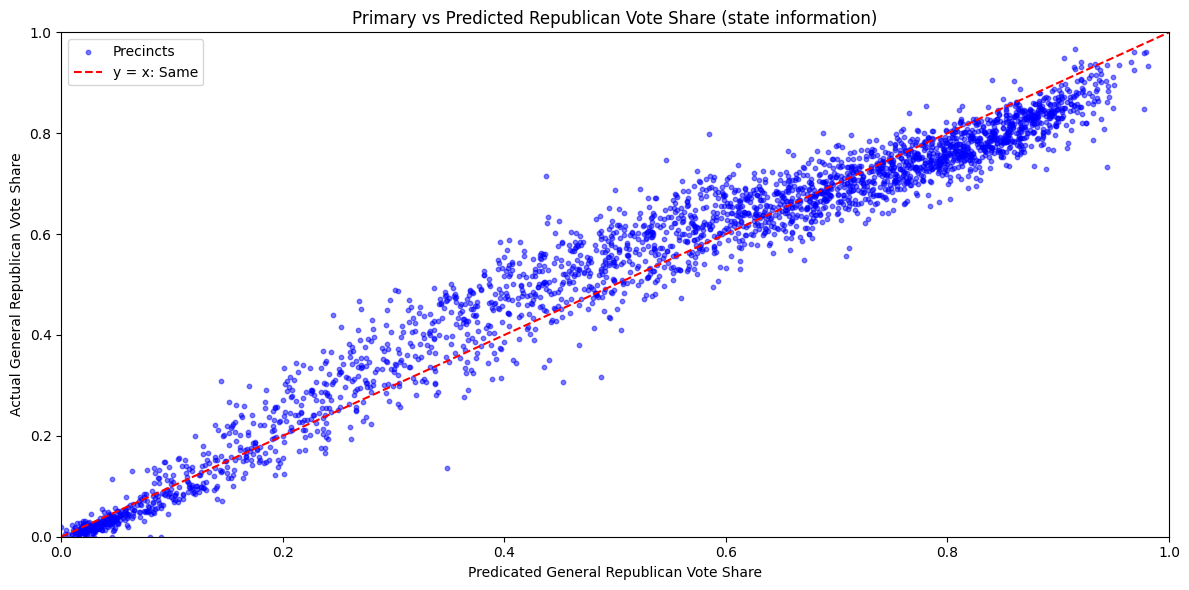

In [139]:
plt.figure(figsize=(12, 6))
plt.scatter(
    x=GA_data['actual_general_rep_share'], 
    y=GA_data['predicted_rep_share_state'], 
    color='blue', label='Precincts', alpha=0.5, s=10
)
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='y = x: Same')
plt.title('Primary vs Predicted Republican Vote Share (state information)')
plt.xlabel('Predicated General Republican Vote Share')
plt.ylabel('Actual General Republican Vote Share')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

## Plotting these 2 effects

In [140]:
GA_data

,precinct,pri_dem_CLINTON,pri_dem_O'MALLEY,pri_dem_SANDERS,pri_dem_STEINBERG,pri_rep_BUSH,pri_rep_CARSON,pri_rep_CHRISTIE,pri_rep_CRUZ,pri_rep_FIORINA,...,primary_winner,predicted_dem_gen,predicted_rep_gen,actual_general_rep_share,predicted_rep_share,primary_rep_voteshare,state_primary_winner,predicted_dem_gen_state,predicted_rep_gen_state,predicted_rep_share_state
0,CHATHAMNAN,19916,72,7507,51,274,1522,50,7055,36,...,rep,46676.551428,50291.001141,0.423123,0.518637,0.526839,rep,45322.136475,41795.049361,0.479757
1,CHEROKEENAN,4844,29,4442,25,168,2524,61,12899,40,...,rep,10927.224687,24742.143069,0.761702,0.693652,0.843465,rep,13403.224660,42728.423803,0.761218
2,HENRYNAN,15795,38,4468,35,161,1705,33,8220,34,...,rep,34288.282386,42751.829663,0.477381,0.554929,0.581779,rep,34435.643620,37869.897489,0.523748
3,FORSYTHNAN,3707,24,3153,12,220,1776,45,9987,34,...,rep,8306.108824,19349.735970,0.748567,0.699662,0.859877,rep,10345.631366,36692.795954,0.780060
4,CLAYTONNAN,25151,60,5557,38,62,531,13,1859,15,...,dem,24816.053953,11965.901255,0.139162,0.325320,0.201421,rep,55912.780844,8860.061413,0.136787
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2812,FORSYTH15 HEARDSVILLE-7,0,0,2,0,0,0,0,1,0,...,rep,2.912564,6.058134,0.818182,0.675325,0.800000,rep,3.436826,8.621190,0.714976
2813,FULTON03P2,5,0,0,0,0,0,0,0,0,...,dem,-0.520794,0.000000,0.045455,-0.000000,0.000000,rep,14.321822,0.000000,0.000000
2814,FORSYTH10 MIDWAY-9,1,0,1,0,0,0,0,1,0,...,rep,2.273778,4.906796,0.944444,0.683343,0.818182,rep,2.725998,7.512342,0.733746
2815,FULTONUC02B,3,0,1,0,0,0,0,4,0,...,dem,7.354592,7.354592,0.375000,0.500000,0.500000,rep,7.030125,5.948567,0.458333


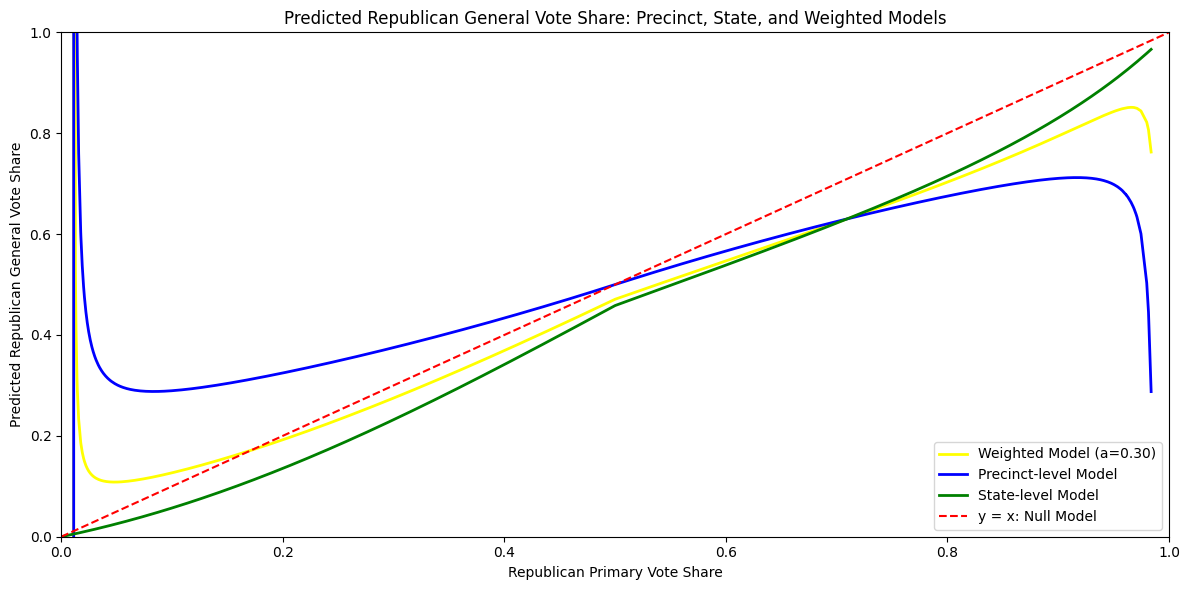

In [141]:
# Create a weighted model: a * precinct + (1 - a) * state
a = 0.3  

GA_data['predicted_rep_share_weighted'] = (
    a * GA_data['predicted_rep_share'] +
    (1 - a) * GA_data['predicted_rep_share_state']
)

# Sort for smooth plotting
sorted_weighted = GA_data.sort_values('primary_rep_voteshare')

plt.figure(figsize=(12, 6))
plt.plot(
    sorted_weighted['primary_rep_voteshare'],
    sorted_weighted['predicted_rep_share_weighted'],
    color='yellow', linewidth=2, label=f'Weighted Model (a={a:.2f})'
)
plt.plot(
    sorted_weighted['primary_rep_voteshare'],
    sorted_weighted['predicted_rep_share'],
    color='blue', linewidth=2, label='Precinct-level Model'
)
plt.plot(
    sorted_weighted['primary_rep_voteshare'],
    sorted_weighted['predicted_rep_share_state'],
    color='green', linewidth=2, label='State-level Model'
)

plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='y = x: Null Model')
plt.title('Predicted Republican General Vote Share: Precinct, State, and Weighted Models')
plt.xlabel('Republican Primary Vote Share')
plt.ylabel('Predicted Republican General Vote Share')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()

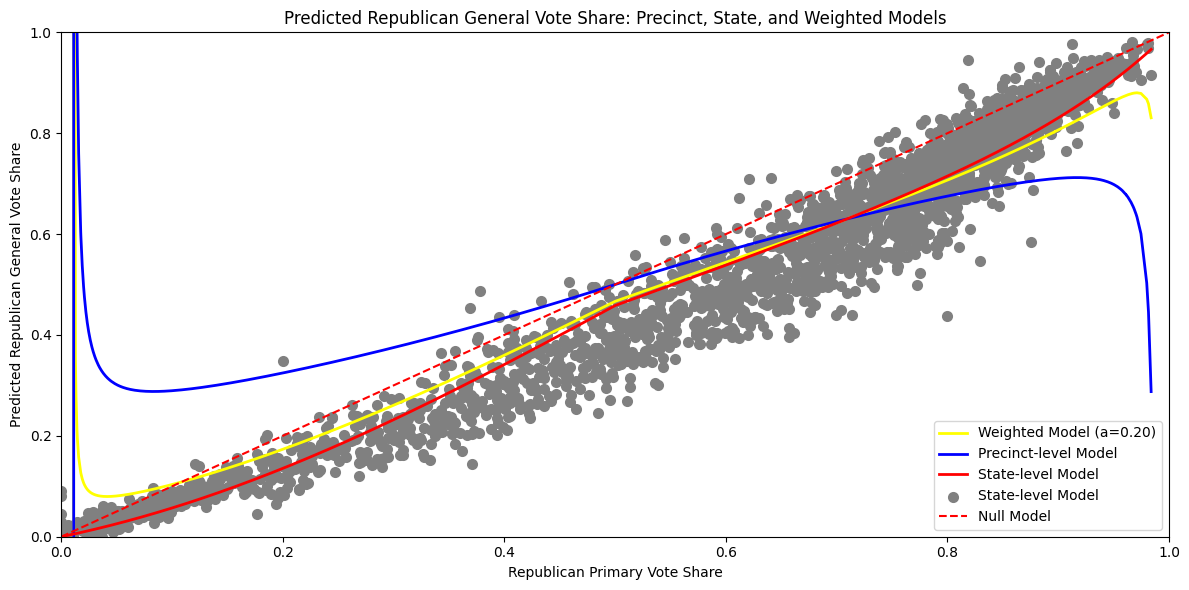

In [142]:
# Create a weighted model: a * precinct + (1 - a) * state
a = 0.2  

GA_data['predicted_rep_share_weighted'] = (
    a * GA_data['predicted_rep_share'] +
    (1 - a) * GA_data['predicted_rep_share_state']
)

# Sort for smooth plotting
sorted_weighted = GA_data.sort_values('primary_rep_voteshare')

plt.figure(figsize=(12, 6))
plt.plot(
    sorted_weighted['primary_rep_voteshare'],
    sorted_weighted['predicted_rep_share_weighted'],
    color='yellow', linewidth=2, label=f'Weighted Model (a={a:.2f})'
)
plt.plot(
    sorted_weighted['primary_rep_voteshare'],
    sorted_weighted['predicted_rep_share'],
    color='blue', linewidth=2, label='Precinct-level Model'
)
plt.plot(
    sorted_weighted['primary_rep_voteshare'],
    sorted_weighted['predicted_rep_share_state'],
    color='red', linewidth=2, label='State-level Model'
)
plt.scatter(
    sorted_weighted['primary_rep_voteshare'],
    sorted_weighted['actual_general_rep_share'],
    color='gray', linewidth=2, label='State-level Model'
)
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Null Model')
plt.title('Predicted Republican General Vote Share: Precinct, State, and Weighted Models')
plt.xlabel('Republican Primary Vote Share')
plt.ylabel('Predicted Republican General Vote Share')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()

(0.0, 1.0)

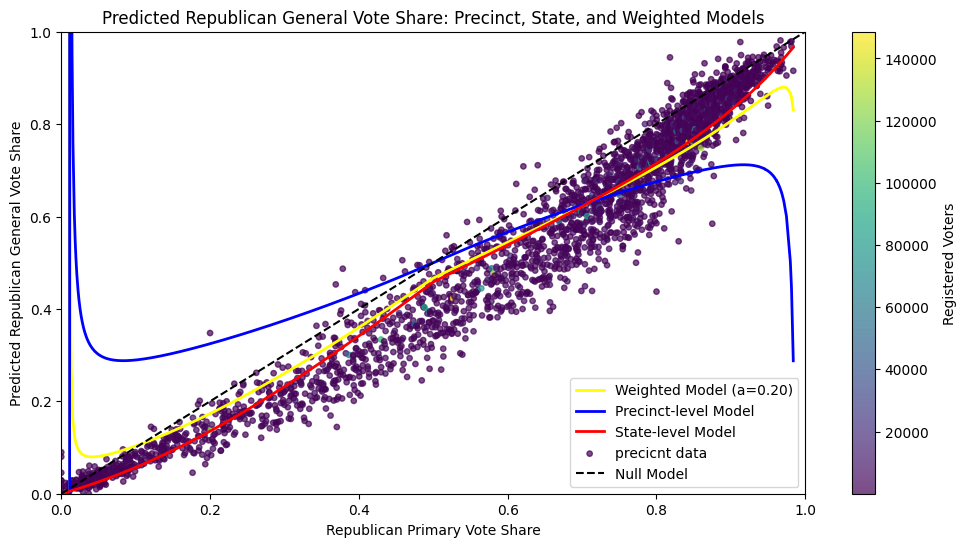

In [143]:
# Create a weighted model: a * precinct + (1 - a) * state
a = 0.2  

GA_data['predicted_rep_share_weighted'] = (
    a * GA_data['predicted_rep_share'] +
    (1 - a) * GA_data['predicted_rep_share_state']
)

# Sort for smooth plotting
sorted_weighted = GA_data.sort_values('primary_rep_voteshare')

plt.figure(figsize=(12, 6))
plt.plot(
    sorted_weighted['primary_rep_voteshare'],
    sorted_weighted['predicted_rep_share_weighted'],
    color='yellow', linewidth=2, label=f'Weighted Model (a={a:.2f})'
)
plt.plot(
    sorted_weighted['primary_rep_voteshare'],
    sorted_weighted['predicted_rep_share'],
    color='blue', linewidth=2, label='Precinct-level Model'
)
plt.plot(
    sorted_weighted['primary_rep_voteshare'],
    sorted_weighted['predicted_rep_share_state'],
    color='red', linewidth=2, label='State-level Model'
)

# Scatter actual values, color by precinct_size
sc = plt.scatter(
    sorted_weighted['primary_rep_voteshare'],
    sorted_weighted['actual_general_rep_share'],
    c=sorted_weighted['precinct_size'],
    cmap='viridis',
    alpha=0.7,
    s=15,
    label='precicnt data'
)
plt.colorbar(sc, label='Registered Voters')

plt.plot([0, 1], [0, 1], color='black', linestyle='--', label='Null Model')
plt.title('Predicted Republican General Vote Share: Precinct, State, and Weighted Models')
plt.xlabel('Republican Primary Vote Share')
plt.ylabel('Predicted Republican General Vote Share')
plt.legend()
plt.xlim(0, 1)
plt.ylim(0, 1)